# Predicción de congestión urbana

## Contexto del problema

El Ayuntamiento de una ciudad inteligente quiere anticipar episodios de congestión alta para apoyar decisiones operativas como ajustes semafóricos o avisos al ciudadano.

Para ello dispone de un dataset con variables de movilidad, contexto meteorológico, operación del transporte y otras señales auxiliares provenientes de sensores distribuidos por la ciudad.

El objetivo es construir un modelo que identifique casos de congestión alta y justificar las decisiones tomadas hasta llegar a un modelo robusto y adaptado a las necesidades operativas del Ayuntamiento.

## Librerias empleadas

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt # modulo especifico de gráficos
import seaborn as sns

## Exploración del caso de uso a estudiar

En esta sección se define el problema antes de tocar los datos. El objetivo es responder a las preguntas clave del caso de uso: qué se quiere predecir, quién usará el modelo y qué decisiones operativas permitirá tomar.

### Carga de datos

In [ ]:
data = pd.read_csv('../data/dataset_smart_urban_mobility.csv')

print(f"Dimensiones dataset", data.shape)
print(f"Columnas del dataset",data.columns)
data.head()

Dimensiones dataset (720, 26)
Columnas del dataset Index(['id_registro', 'fecha', 'dia_semana_num', 'distrito', 'tipo_dia',
       'franja_horaria', 'id_sensor', 'temperatura_c', 'humedad_relativa_pct',
       'lluvia_mm', 'viento_kmh', 'evento_ciudad', 'obras_viales',
       'festivo_local', 'aforo_vehiculos', 'accidentes_previos_24h',
       'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct',
       'numero_incidencias_app', 'indice_ruido_historico',
       'color_semaforo_dominante', 'campana_publicitaria',
       'porcentaje_hombres_zona', 'indice_congestion', 'congestion_alta'],
      dtype='str')


,id_registro,fecha,dia_semana_num,distrito,tipo_dia,franja_horaria,id_sensor,temperatura_c,humedad_relativa_pct,lluvia_mm,...,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,color_semaforo_dominante,campana_publicitaria,porcentaje_hombres_zona,indice_congestion,congestion_alta
0,1,2025-01-01,2,Centro,Laborable,Mañana,S-050,14.1,61.0,3.5,...,71.9,168.0,30.4,8.0,91.5,Verde,0,52.3,68.7,1
1,2,2025-01-01,2,Centro,Laborable,Mañana,S-028,12.6,54.0,12.9,...,70.4,73.0,24.9,8.0,97.6,Amarillo,0,52.8,62.2,1
2,3,2025-01-02,3,Este,Laborable,Tarde,S-003,22.0,39.0,2.8,...,75.8,136.0,42.4,9.0,100.2,Rojo,1,50.0,62.5,0
3,4,2025-01-02,3,Universidad,Laborable,Mañana,S-032,22.6,49.0,0.4,...,88.0,142.0,38.0,7.0,93.1,Amarillo,0,52.7,61.8,1
4,5,2025-01-03,4,Centro,Laborable,Tarde,S-001,19.3,44.0,3.6,...,79.1,141.0,21.0,12.0,96.2,Rojo,0,54.3,77.5,1


El dataset tiene 720 registros o observaciones y 26 variables o columnas

Para entender mejor qué representa cada fila del dataset, veamos un registro concreto:

In [3]:
data.head(1)

,id_registro,fecha,dia_semana_num,distrito,tipo_dia,franja_horaria,id_sensor,temperatura_c,humedad_relativa_pct,lluvia_mm,...,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,color_semaforo_dominante,campana_publicitaria,porcentaje_hombres_zona,indice_congestion,congestion_alta
0,1,2025-01-01,2,Centro,Laborable,Mañana,S-050,14.1,61.0,3.5,...,71.9,168.0,30.4,8.0,91.5,Verde,0,52.3,68.7,1


| Campo | Valor | Interpretación |
|---|---|---|
| `id_registro` | 1 | Primera fila del dataset |
| `fecha` | 2025-01-01 | 1 de enero de 2025 |
| `dia_semana_num` | 2 | Miércoles |
| `distrito` | Centro | Distrito Centro de la ciudad |
| `tipo_dia` | Laborable | Día entre semana |
| `franja_horaria` | Mañana | Registro tomado por la mañana |
| `id_sensor` | S-050 | Sensor número 50 |
| `temperatura_c` | 14.1°C | Temperatura fresca, típica de enero |
| `humedad_relativa_pct` | 61% | Humedad moderada |
| `lluvia_mm` | 3.5mm | Lluvia ligera |
| `ocupacion_bus_pct` | 71.9% | El autobús va bastante lleno |
| `plazas_aparcamiento_libres` | 168 | Bastantes plazas libres |
| `ocupacion_bici_pct` | 30.4% | Uso moderado de bicicletas |
| `numero_incidencias_app` | 8 | 8 incidencias reportadas por usuarios |
| `indice_ruido_historico` | 91.5 | Zona ruidosa |
| `color_semaforo_dominante` | Verde | Semáforos en verde predominantemente |
| `campana_publicitaria` | 0 | Sin campaña publicitaria activa |
| `porcentaje_hombres_zona` | 52.3% | Distribución casi equitativa por género |
| `indice_congestion` | 68.7 | Nivel de congestión moderado-alto |
| `congestion_alta` | **1** | **Hay congestión alta** |

Es decir, este registro representa una mañana de miércoles laborable en el distrito Centro, con lluvia ligera, autobuses bastante ocupados y 8 incidencias reportadas en la app. El resultado es congestión alta.

### Exploración de las variables 

El objetivo en esta sección es poder presentar una tabla con todas las variables y lo que significa cada una. Antes de nada, exploramos las distintas variables:

In [4]:
print(data['id_registro'].nunique()) # id_registro es un indice de las filas, hay tantos como filas
print(data['fecha'].value_counts().head(3)) # fecha del registro
print(data['dia_semana_num'].value_counts()) # dia de la semana codificado numericamente de L-D 0-6
print(data['distrito'].value_counts()) # distrito del registro
print(f"La variable distrito tiene estas opciones",data['distrito'].unique())

720
fecha
2025-01-01    2
2025-01-02    2
2025-01-03    2
Name: count, dtype: int64
dia_semana_num
2    104
3    104
4    104
5    102
6    102
0    102
1    102
Name: count, dtype: int64
distrito
Centro         136
Este           123
Norte          123
Universidad    118
Oeste          108
Sur            103
Name: count, dtype: int64
La variable distrito tiene estas opciones <StringArray>
['Centro', 'Este', 'Universidad', 'Sur', 'Oeste', 'Norte', nan]
Length: 7, dtype: str


In [5]:
print(data['tipo_dia'].value_counts()) # laborable o fin de semana
print(data['franja_horaria'].value_counts()) # tarde,mañana o noche
print(f"Número de sensores unicos con id del tipo S-Número:",data['id_sensor'].nunique()) # 50 sensores unicos 

tipo_dia
Laborable        516
Fin de semana    204
Name: count, dtype: int64
franja_horaria
Tarde     277
Mañana    274
Noche     160
Name: count, dtype: int64
Número de sensores unicos con id del tipo S-Número: 50


In [6]:
# variables numéricas claras
data[['temperatura_c', 'humedad_relativa_pct',
       'lluvia_mm', 'viento_kmh',  'aforo_vehiculos', 'accidentes_previos_24h',
       'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct',
       'numero_incidencias_app', 'indice_ruido_historico',
       'porcentaje_hombres_zona', 'indice_congestion']].describe()

,temperatura_c,humedad_relativa_pct,lluvia_mm,viento_kmh,aforo_vehiculos,accidentes_previos_24h,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,porcentaje_hombres_zona,indice_congestion
count,713.000000,716.000000,710.000000,717.000000,720.000000,715.000000,715.000000,718.000000,718.000000,716.000000,717.000000,720.000000,720.000000
mean,16.609397,58.925978,3.344366,12.745328,1503.355556,3.724476,69.385874,179.792479,35.278969,7.956704,88.024826,51.535833,61.268333
std,7.444073,13.787553,4.044703,4.841579,473.639389,1.334062,13.294684,49.651366,10.261256,3.160432,11.891769,1.278394,11.296092
min,-10.100000,25.000000,0.000000,0.000000,350.000000,0.000000,28.500000,31.000000,1.200000,0.000000,58.400000,48.000000,23.900000
25%,11.100000,49.000000,0.300000,9.500000,1184.750000,3.000000,60.900000,147.000000,28.000000,6.000000,80.200000,50.600000,54.075000
50%,16.400000,59.000000,2.100000,12.700000,1522.000000,4.000000,69.900000,179.000000,34.850000,8.000000,88.100000,51.600000,61.850000
75%,22.200000,68.000000,4.800000,15.800000,1842.250000,5.000000,78.700000,211.000000,42.200000,10.000000,96.000000,52.500000,68.525000
max,38.000000,95.000000,28.500000,28.300000,2785.000000,7.000000,100.000000,327.000000,66.900000,18.000000,125.000000,55.200000,92.600000


In [7]:
data['color_semaforo_dominante'].value_counts()

color_semaforo_dominante
Verde       266
Rojo        235
Amarillo    219
Name: count, dtype: int64

In [8]:
# variables binarias
print(data['evento_ciudad'].unique())
print(data['obras_viales'].unique())
print(data[ 'festivo_local'].unique())
print(data['campana_publicitaria'].unique())

[0 1]
[0 1]
[0 1]
[0 1]


In [9]:
# episodios de congestión alta
data['congestion_alta'].value_counts()

congestion_alta
1    531
0    189
Name: count, dtype: int64

| Variable | Tipo | Descripción |
|---|---|---|
| `id_registro` | Índice | Identificador único de cada fila, no aporta información predictiva |
| `fecha` | Fecha | Fecha del registro (2025, datos diarios) |
| `dia_semana_num` | Numérica discreta | Día de la semana codificado de 0 (lunes) a 6 (domingo) |
| `distrito` | Categórica | Distrito de la ciudad: Centro, Este, Norte, Sur, Oeste, Universidad. Tiene valores nulos |
| `tipo_dia` | Categórica binaria | Laborable o Fin de semana |
| `franja_horaria` | Categórica | Franja del día: Mañana, Tarde, Noche |
| `id_sensor` | Categórica | Identificador del sensor que recoge el registro. 50 sensores únicos |
| `temperatura_c` | Numérica continua | Temperatura en grados Celsius. Rango de -10 a 38°C. Tiene valores nulos |
| `humedad_relativa_pct` | Numérica continua | Humedad relativa en porcentaje (25-95%). Tiene valores nulos |
| `lluvia_mm` | Numérica continua | Precipitación en milímetros. Tiene valores nulos |
| `viento_kmh` | Numérica continua | Velocidad del viento en km/h. Tiene valores nulos |
| `evento_ciudad` | Binaria (0/1) | Si hay un evento en la ciudad ese día |
| `obras_viales` | Binaria (0/1) | Si hay obras en la vía ese día |
| `festivo_local` | Binaria (0/1) | Si es festivo local |
| `aforo_vehiculos` | Numérica continua | Número de vehículos registrados por el sensor (350-2785) |
| `accidentes_previos_24h` | Numérica discreta | Número de accidentes en las últimas 24 horas. Tiene valores nulos |
| `ocupacion_bus_pct` | Numérica continua | Porcentaje de ocupación del autobús (28-100%). Tiene valores nulos |
| `plazas_aparcamiento_libres` | Numérica continua | Número de plazas de aparcamiento libres. Tiene valores nulos |
| `ocupacion_bici_pct` | Numérica continua | Porcentaje de ocupación del servicio de bicicletas. Tiene valores nulos |
| `numero_incidencias_app` | Numérica discreta | Número de incidencias reportadas por usuarios en la app. Tiene valores nulos |
| `indice_ruido_historico` | Numérica continua | Índice de ruido histórico de la zona. Tiene valores nulos |
| `color_semaforo_dominante` | Categórica | Color de semáforo predominante en la zona |
| `campana_publicitaria` | Binaria (0/1) | Si hay campaña publicitaria activa en la zona |
| `porcentaje_hombres_zona` | Numérica continua | Porcentaje de hombres en la zona (48-55%) |
| `indice_congestion` | Numérica continua | Índice numérico de congestión (23.9-92.6) |
| `congestion_alta` | Binaria (0/1) — **variable objetivo** | Si hay congestión alta (1) o no (0). 531 casos positivos de 720 |

### Identificación de la variable objetivo

La variable objetivo es `congestion_alta`, una variable binaria que indica si en ese registro se ha producido un episodio de congestión alta (1) o no (0).

In [10]:
data['congestion_alta'].value_counts()

congestion_alta
1    531
0    189
Name: count, dtype: int64

In [11]:
data['congestion_alta'].value_counts(normalize=True) * 100 # porcentajes

congestion_alta
1    73.75
0    26.25
Name: proportion, dtype: float64

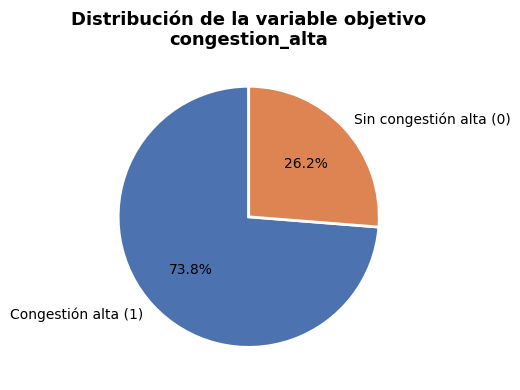

In [12]:
conteo_target = data['congestion_alta'].value_counts()

plt.figure(figsize=(6, 4))
plt.pie(
    conteo_target.values,
    labels=[ 'Congestión alta (1)','Sin congestión alta (0)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Distribución de la variable objetivo\ncongestion_alta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Del total de 720 registros, 531 corresponden a congestión alta y 189 a no congestión. Esto significa que el dataset está **desbalanceado**. El 73.75% de los casos son positivos. Este desbalance es importante tenerlo en cuenta a la hora de entrenar el modelo, ya que un clasificador que predijera siempre congestión alta acertaría el 73.75% de las veces sin aprender nada útil.

Otra variable que podría generar dudas es `indice_congestion`. Esta variable numérica continua podría usarse como variable objetivo si el problema fuera de **regresión**, es decir, si quisiéramos predecir el nivel exacto de congestión como un número.

Sin embargo, el problema está planteado como **clasificación binaria**: predecir si hay congestión alta o no. Por eso la variable objetivo es `congestion_alta` (0 o 1), no `indice_congestion`.

Es muy probable que `congestion_alta` se haya derivado directamente de `indice_congestion` aplicando un umbral fijo:

- congestion_alta = 1  si  indice_congestion > umbral X
- congestion_alta = 0  si  indice_congestion ≤ umbral X

Si esto es así, los registros con `congestion_alta = 0` deberían tener valores de `indice_congestion` siempre por debajo de ese umbral, y los de `congestion_alta = 1` siempre por encima. Vemos si esta afirmación es correcta:

In [13]:
data['indice_congestion'].describe()

count    720.000000
mean      61.268333
std       11.296092
min       23.900000
25%       54.075000
50%       61.850000
75%       68.525000
max       92.600000
Name: indice_congestion, dtype: float64

In [14]:
data.groupby('congestion_alta')['indice_congestion'].describe()

,count,mean,std,min,25%,50%,75%,max
congestion_alta,,,,,,,,
0,189.0,53.692593,9.994208,23.9,47.00,54.5,60.60,79.9
1,531.0,63.964783,10.484446,33.9,57.05,64.0,70.85,92.6


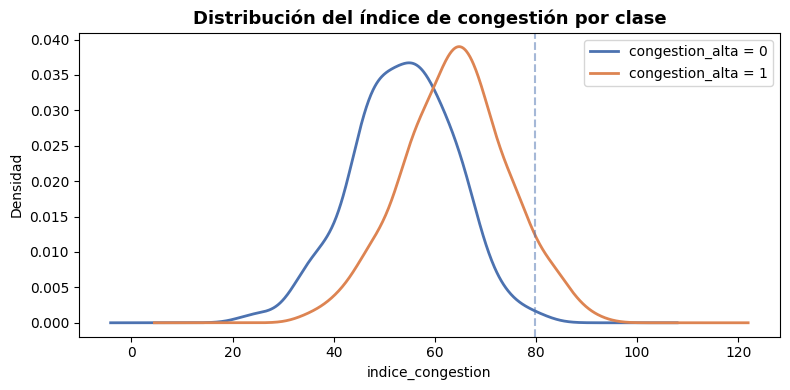

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = data[data['congestion_alta'] == label]['indice_congestion']
    subset.plot(kind='kde', ax=ax, label=f'congestion_alta = {label}', color=color, linewidth=2)

ax.set_title('Distribución del índice de congestión por clase', fontsize=13, fontweight='bold')
ax.set_xlabel('indice_congestion')
ax.set_ylabel('Densidad')
ax.legend()
ax.axvline(x=data[data['congestion_alta']==0]['indice_congestion'].max(), 
           color='#4C72B0', linestyle='--', alpha=0.5, label='Máx clase 0')
plt.tight_layout()
plt.show()

El gráfico de densidad muestra la distribución del índice de congestión separada por clase:

- La curva azul (congestion_alta = 0) se concentra alrededor de 54 puntos
- La curva naranja (congestion_alta = 1) se concentra alrededor de 64 puntos
- Las curvas **se solapan significativamente** —> no existe un umbral fijo que separe perfectamente ambas clases

Esto descarta la hipótesis de que `congestion_alta` se derive de aplicar un corte limpio sobre `indice_congestion`. La separación entre clases existe pero no es perfecta.

A pesar de esto, `indice_congestion` no debe usarse como variable predictora en el modelo por dos razones:

1. **Data leakage**: ambas variables miden el mismo fenómeno. Si en producción tuviéramos el índice de congestión disponible, ya sabríamos directamente si hay congestión alta o no, haciendo innecesario el modelo.
2. **El objetivo real del modelo** : es anticipar la congestión usando variables previas al evento, meteorología, aforo, franja horaria, incidencias, no variables que describen el propio evento.

Por tanto, `indice_congestion` se debe excluir del conjunto de variables predictoras.

### Act 1: Caso de uso

La primera actividad nos pide definir el problema antes de tocar los datos. Más allá de identificar la variable objetivo, el objetivo es responder a tres preguntas clave:

- **¿Qué predice el modelo?** — qué información concreta genera como salida
- **¿Quién usaría esa predicción?** — qué perfil de usuario o equipo tomaría decisiones a partir de ella
- **¿Qué decisiones operativas permitiría tomar?** — cómo se traduciría la predicción en acciones reales sobre la ciudad

Definir esto antes de entrenar cualquier modelo es fundamental. Sin entender quién va a usar la predicción y para qué, es imposible saber qué métrica optimizar, qué tipo de error es más costoso o si el modelo tiene sentido en producción.


| Elemento | Respuesta |
|---|---|
| **Variable objetivo** | `congestion_alta` — variable binaria que indica si hay congestión alta (1) o no (0) |
| **Qué predice el modelo** | La probabilidad de que se produzca un episodio de congestión alta en un distrito y franja horaria determinados, a partir de variables de movilidad, meteorología y contexto urbano |
| **Quién usaría la predicción** | El equipo de operaciones de movilidad urbana del Ayuntamiento — técnicos que monitorizan el tráfico en tiempo real y toman decisiones sobre la gestión de la ciudad |
| **Decisión operativa 1** | **Ajuste semafórico predictivo** — modificar los ciclos de semáforos en los accesos al distrito antes de que se forme el atasco para fluidificar la entrada de vehículos |
| **Decisión operativa 2** | **Aviso anticipado a ciudadanos** — lanzar notificaciones push en la app municipal avisando de congestión esperada para que los usuarios elijan rutas alternativas o transporte público |
| **Decisión operativa 3** | **Refuerzo de líneas de autobús** — activar autobuses extra en las líneas que atraviesan la zona antes de que se produzca el episodio |
| **Decisión operativa 4** | **Cierre preventivo de accesos** — cortar el acceso de vehículos privados a zonas con alta probabilidad de congestión y redirigirlos por vías alternativas |
| **Decisión operativa 5** | **Activación de agentes de tráfico** — desplegar agentes en los puntos críticos predichos antes de que la congestión se materialice, en lugar de enviarlos cuando ya es tarde |

## Comprensión del dataset

En esta sección se analiza el dataset antes de entrenar ningún modelo. El objetivo es identificar qué variables parecen útiles para predecir la congestión alta, cuáles podrían ser irrelevantes o introducir ruido, cuáles podrían causar sesgo y cuáles necesitan algún tipo de transformación antes de ser usadas. Como se indica en el enunciado, no es necesario acertar en todo desde el principio, pero sí justificar las hipótesis iniciales con lo que se observa en los datos.

In [16]:
# recordamos las variables del dataset
data.columns.tolist()

['id_registro',
 'fecha',
 'dia_semana_num',
 'distrito',
 'tipo_dia',
 'franja_horaria',
 'id_sensor',
 'temperatura_c',
 'humedad_relativa_pct',
 'lluvia_mm',
 'viento_kmh',
 'evento_ciudad',
 'obras_viales',
 'festivo_local',
 'aforo_vehiculos',
 'accidentes_previos_24h',
 'ocupacion_bus_pct',
 'plazas_aparcamiento_libres',
 'ocupacion_bici_pct',
 'numero_incidencias_app',
 'indice_ruido_historico',
 'color_semaforo_dominante',
 'campana_publicitaria',
 'porcentaje_hombres_zona',
 'indice_congestion',
 'congestion_alta']

In [17]:
data.dtypes # vemos tipos antes de proceder

id_registro                     int64
fecha                             str
dia_semana_num                  int64
distrito                          str
tipo_dia                          str
franja_horaria                    str
id_sensor                         str
temperatura_c                 float64
humedad_relativa_pct          float64
lluvia_mm                     float64
viento_kmh                    float64
evento_ciudad                   int64
obras_viales                    int64
festivo_local                   int64
aforo_vehiculos                 int64
accidentes_previos_24h        float64
ocupacion_bus_pct             float64
plazas_aparcamiento_libres    float64
ocupacion_bici_pct            float64
numero_incidencias_app        float64
indice_ruido_historico        float64
color_semaforo_dominante          str
campana_publicitaria            int64
porcentaje_hombres_zona       float64
indice_congestion             float64
congestion_alta                 int64
dtype: objec

### Correlación de variables numéricas con la variable objetivo

La correlación mide la relación lineal entre dos variables numéricas. En este caso, al ser `congestion_alta` una variable binaria (0/1), lo que calculamos es la correlación punto-biserial, es decir, qué tanto sube o baja la probabilidad de congestión alta cuando una variable numérica aumenta.

El resultado va de -1 a 1. Cercano a 1 significa que cuando la variable sube, la congestión alta tiende a ocurrir más. Cercano a -1 significa que cuando la variable sube, la congestión alta tiende a ocurrir menos. Cercano a 0 indica que la variable no tiene relación lineal con la congestión alta.

Es importante tener en cuenta que la correlación solo detecta relaciones lineales. Una variable puede ser muy útil para el modelo aunque su correlación sea baja, si su relación con el target es no lineal.

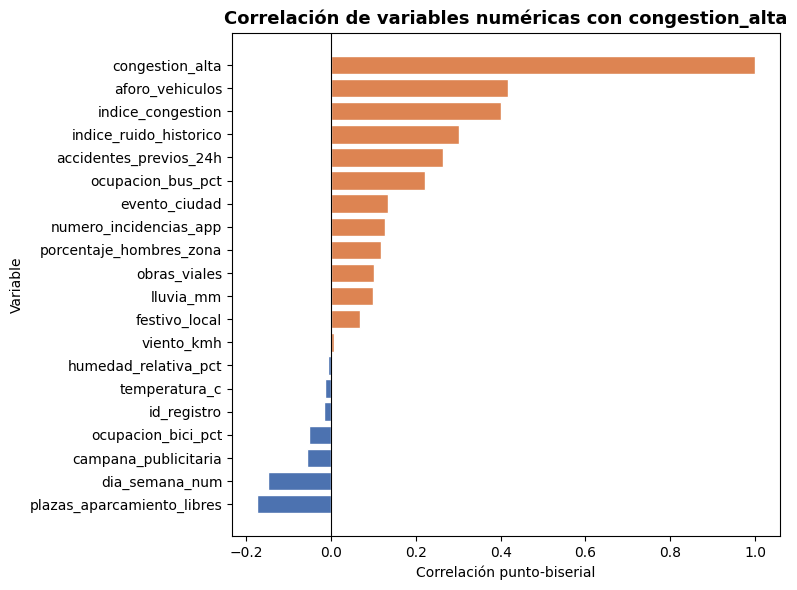

In [18]:
correlaciones = data.corr(numeric_only=True)['congestion_alta'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Correlación de variables numéricas con congestion_alta', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación punto-biserial')
ax.set_ylabel('Variable')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

El gráfico muestra la correlación punto-biserial de cada variable numérica con `congestion_alta`. Las barras naranjas indican correlación positiva (cuando la variable sube, aumenta la probabilidad de congestión alta) y las azules correlación negativa (cuando la variable sube, disminuye la probabilidad de congestión alta).

**Variables más correlacionadas positivamente:**

`aforo_vehiculos` es la variable más correlacionada con el target (0.42), excluyendo `indice_congestion` que como ya vimos no puede usarse como predictor por data leakage. Cuantos más vehículos registra el sensor, más probable es que haya congestión alta. `indice_ruido_historico` (0.30) y `accidentes_previos_24h` (0.26) también muestran una relación positiva relevante. `ocupacion_bus_pct` (0.22) indica que cuando el autobús va lleno, la congestión tiende a ser mayor, probablemente porque refleja una demanda de movilidad elevada en la zona.

**Variables con correlación baja:**

`viento_kmh`, `humedad_relativa_pct` y `temperatura_c` tienen correlaciones prácticamente nulas, lo que sugiere que las condiciones meteorológicas de este tipo no tienen relación lineal con la congestión. Esto no significa que sean inútiles para el modelo, ya que pueden tener relaciones no lineales que la correlación no captura.

**Variables correlacionadas negativamente:**

`plazas_aparcamiento_libres` (-0.17) muestra que cuando hay más plazas libres, hay menos congestión, lo cual es coherente. `dia_semana_num` (-0.15) indica que los días más avanzados de la semana tienden a tener ligeramente menos congestión. `campana_publicitaria` (-0.06) tiene una correlación negativa muy leve que probablemente sea ruido estadístico sin interpretación clara.

**Nota importante:** `id_registro` aparece en el gráfico pero es simplemente el índice de las filas y no debe usarse como predictor.

### Distribución de variables numéricas por clase

Para profundizar en la relación entre cada variable numérica y la variable objetivo, visualizamos la distribución de cada una separada por clase (congestion_alta = 0 y congestion_alta = 1). 

Esto nos permite ver no solo si hay diferencia de media entre clases, como ya vimos con la correlación, sino también si las distribuciones se solapan mucho o poco. Cuanto menos se solapen las curvas de ambas clases, más útil será esa variable para que el modelo distinga entre congestión alta y no congestión. Si las curvas se superponen casi por completo, la variable aportará poco poder discriminativo al modelo.

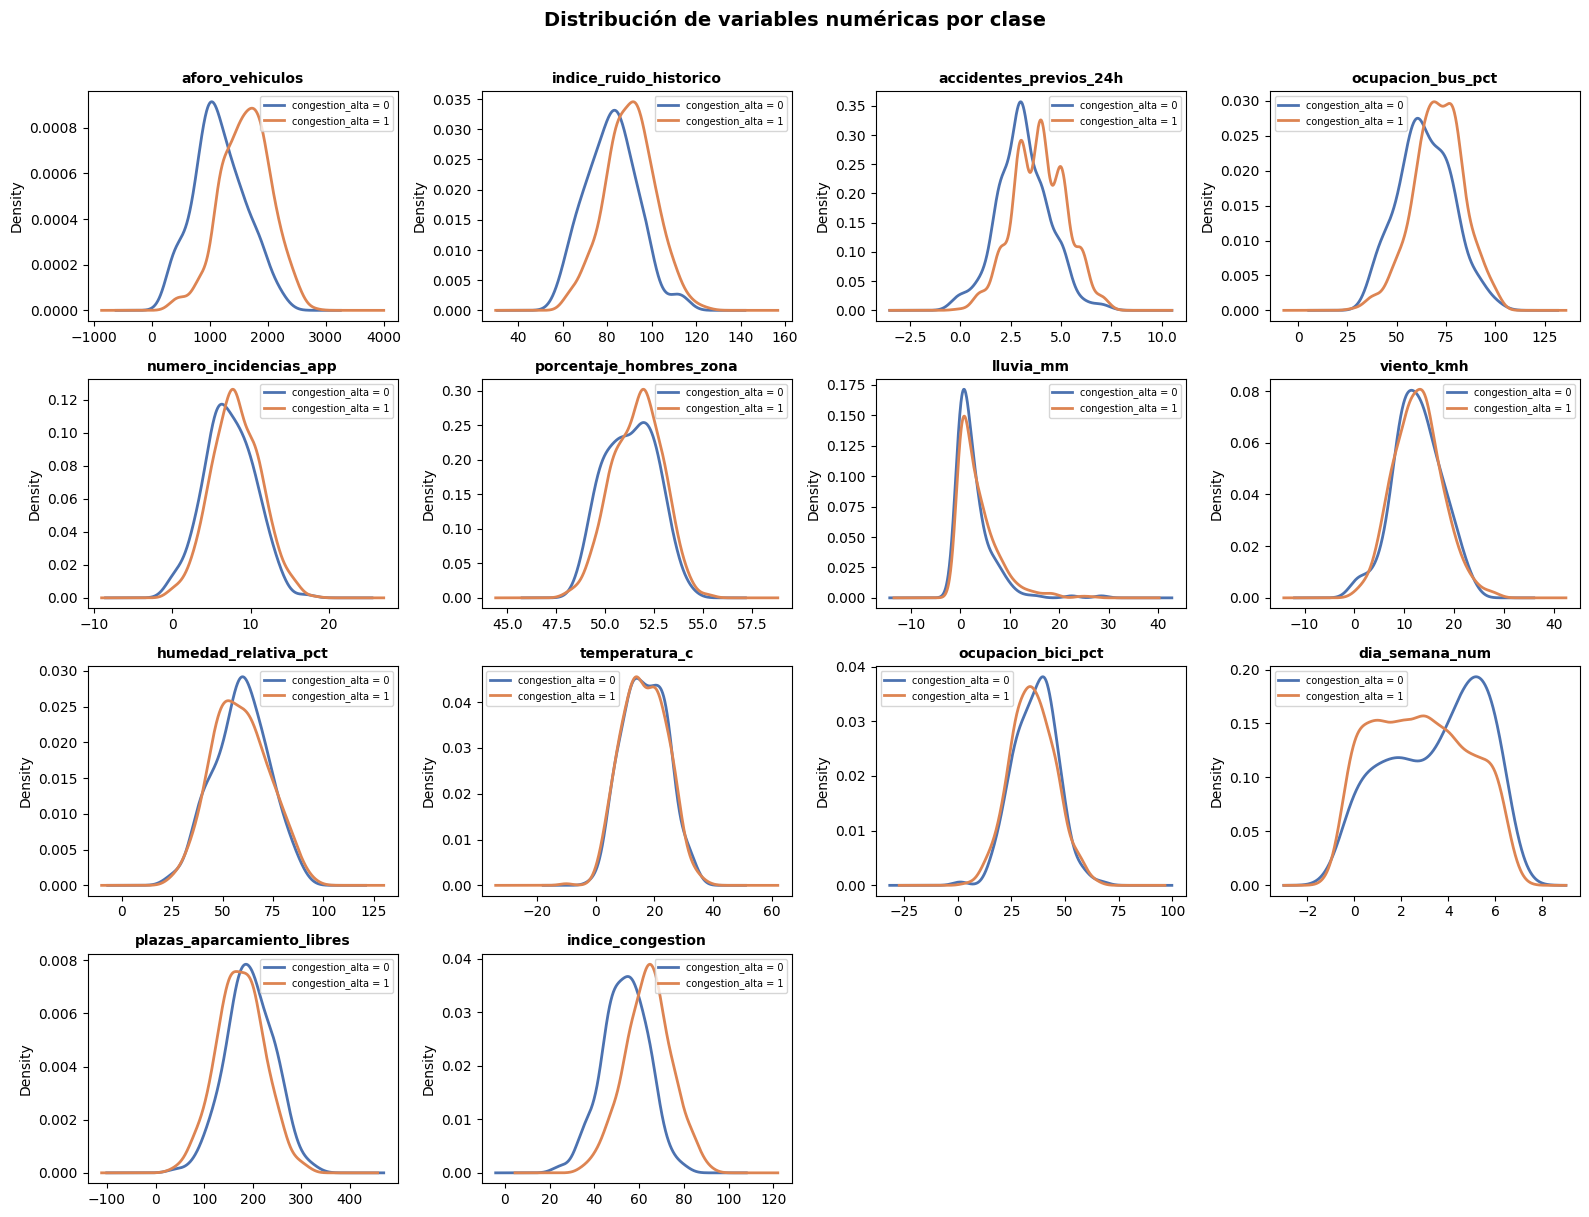

In [20]:
variables_numericas = [
    'aforo_vehiculos', 'indice_ruido_historico', 'accidentes_previos_24h',
    'ocupacion_bus_pct', 'numero_incidencias_app', 'porcentaje_hombres_zona',
    'lluvia_mm', 'viento_kmh', 'humedad_relativa_pct', 'temperatura_c',
    'ocupacion_bici_pct', 'dia_semana_num', 'plazas_aparcamiento_libres','indice_congestion'
]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        subset = data[data['congestion_alta'] == label][var].dropna()
        subset.plot(kind='kde', ax=axes[i], label=f'congestion_alta = {label}', color=color, linewidth=2)
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)

for j in range(len(variables_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas por clase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

El gráfico de densidades permite visualizar cómo se distribuye cada variable numérica según si hay congestión alta o no. Cuanto menos se solapen las curvas azul y naranja, más poder discriminativo tiene esa variable para el modelo.

**Variables con buena separación entre clases:**

`aforo_vehiculos` muestra las curvas claramente desplazadas entre clases, siendo la variable con mayor poder discriminativo de todas las analizadas. `plazas_aparcamiento_libres` también presenta una separación clara, con la clase sin congestión concentrada en valores más altos de plazas libres, lo cual es coherente. `dia_semana_num` muestra distribuciones distintas entre clases, confirmando que el día de la semana influye en la congestión.

**Variables con separación moderada:**

`accidentes_previos_24h`, `ocupacion_bus_pct` y `numero_incidencias_app` muestran cierto desplazamiento entre curvas aunque con solapamiento considerable. Pueden aportar información útil al modelo aunque no sean tan discriminativas como el aforo.

**Variables con curvas prácticamente idénticas:**

`viento_kmh`, `humedad_relativa_pct` y `temperatura_c` muestran distribuciones casi idénticas para ambas clases, confirmando la baja correlación observada anteriormente. Su aportación al modelo será probablemente limitada.


> **Nota sobre la correlación punto-biserial:** La correlación no es más que una forma de resumir en un solo número la diferencia entre los dos grupos que vemos en el gráfico. Se calcula comparando la media de cada variable en el grupo con congestión alta y en el grupo sin congestión alta, en relación a la variabilidad total de esa variable:
>
> $$r = \frac{\bar{X}_1 - \bar{X}_0}{s} \cdot \sqrt{\frac{n_1 \cdot n_0}{n^2}}$$
>
> Donde $\bar{X}_1$ es la media de la variable en el grupo con congestión alta, $\bar{X}_0$ es la media en el grupo sin congestión, $s$ es la desviación típica global de la variable, $n_1$ y $n_0$ son el número de casos de cada clase y $n$ el total. Si la media del grupo con congestión es muy distinta a la del grupo sin congestión, la correlación será alta. Si las medias son parecidas, la correlación será cercana a cero.

### Relación de variables categóricas con la variable objetivo

Para las variables categóricas no tiene sentido calcular correlación, ya que sus valores son etiquetas y no números con orden. En su lugar, calculamos la tasa de congestión alta por categoría, es decir, qué porcentaje de registros de cada categoría tiene `congestion_alta = 1`.

Si una categoría tiene una tasa muy distinta al resto, significa que esa variable tiene poder discriminativo para el modelo. Si todas las categorías tienen tasas similares, la variable aportará poco.

Las variables que analizamos son `distrito`, `tipo_dia`, `franja_horaria` y `color_semaforo_dominante`. Además incluimos `dia_semana_num` tratándola como categórica, ya que aunque está codificada numéricamente sus valores representan días concretos de la semana y no una magnitud continua, por lo que tiene más sentido analizarla como grupo que como número(como hicimos anteriormente).

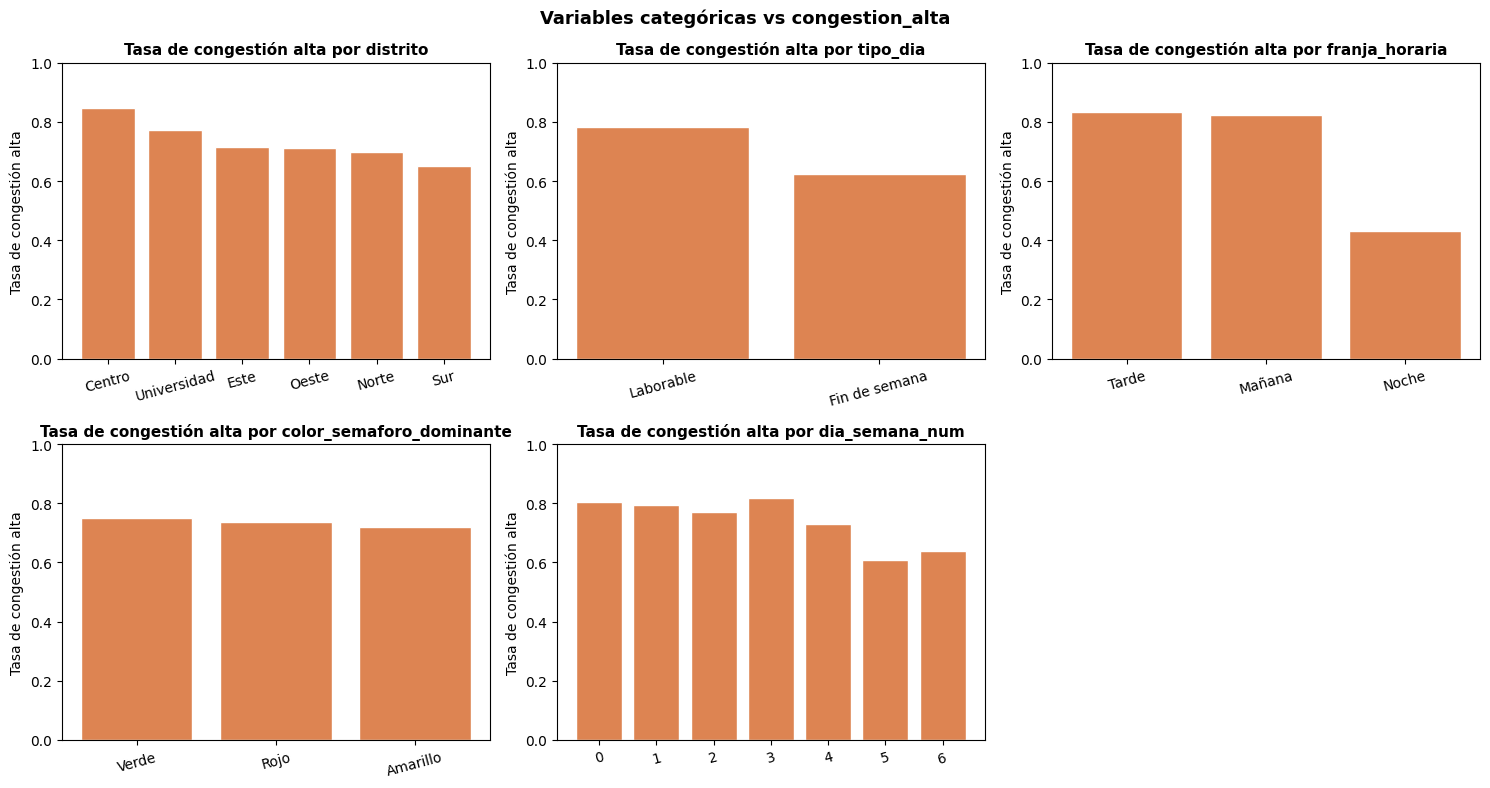

In [23]:
categoricas = ['distrito', 'tipo_dia', 'franja_horaria', 'color_semaforo_dominante', 'dia_semana_num']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(categoricas):
    tasa = data.groupby(var)['congestion_alta'].mean().sort_values(ascending=False)
    axes[i].bar(tasa.index, tasa.values, color='#DD8452', edgecolor='white')
    axes[i].set_title(f'Tasa de congestión alta por {var}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tasa de congestión alta')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=15)

axes[-1].set_visible(False)
plt.suptitle('Variables categóricas vs congestion_alta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Distrito:** El distrito Centro tiene la tasa de congestión alta más elevada (0.85), seguido de Universidad (0.77). El distrito Sur es el menos congestionado (0.65). Hay diferencias relevantes entre distritos, lo que indica que esta variable aportará información útil al modelo.

**Tipo de día:** Los días laborables tienen una tasa de congestión alta del 0.78 frente al 0.63 de los fines de semana. La diferencia es clara y tiene sentido, hay más tráfico entre semana por desplazamientos al trabajo.

**Franja horaria:** Es la variable categórica con mayor poder discriminativo. La tarde y la mañana tienen tasas muy altas (0.83 y 0.82) mientras que la noche cae hasta 0.44. Esto tiene todo el sentido ya que de noche hay mucho menos tráfico.

**Color semáforo dominante:** Las tres categorías (Verde, Rojo y Amarillo) tienen tasas muy similares entre sí, alrededor de 0.72. Esta variable prácticamente no discrimina entre clases y probablemente aporte poco al modelo.

**Día de la semana:** Los días entre semana (0 a 3, lunes a jueves) tienen tasas de congestión alta entre 0.77 y 0.82, mientras que el sábado (5) baja hasta 0.60. El patrón es coherente con lo que vimos en `tipo_dia`. Tratada como categórica resulta más informativa que como numérica continua.

### Relación de variables binarias con la variable objetivo

Las variables binarias solo toman dos valores: 0 (ausencia) y 1 (presencia). Para analizar su relación con `congestion_alta` calculamos la tasa de congestión alta cuando la variable vale 0 y cuando vale 1, y comparamos ambas tasas.

Si la tasa de congestión alta es muy distinta entre el grupo con valor 0 y el grupo con valor 1, la variable tiene poder discriminativo. Si las tasas son similares, la variable aportará poco al modelo.

Las variables binarias que analizamos son `evento_ciudad` (si hay un evento en la ciudad), `obras_viales` (si hay obras en la vía), `festivo_local` (si es festivo local) y `campana_publicitaria` (si hay campaña publicitaria activa en la zona).

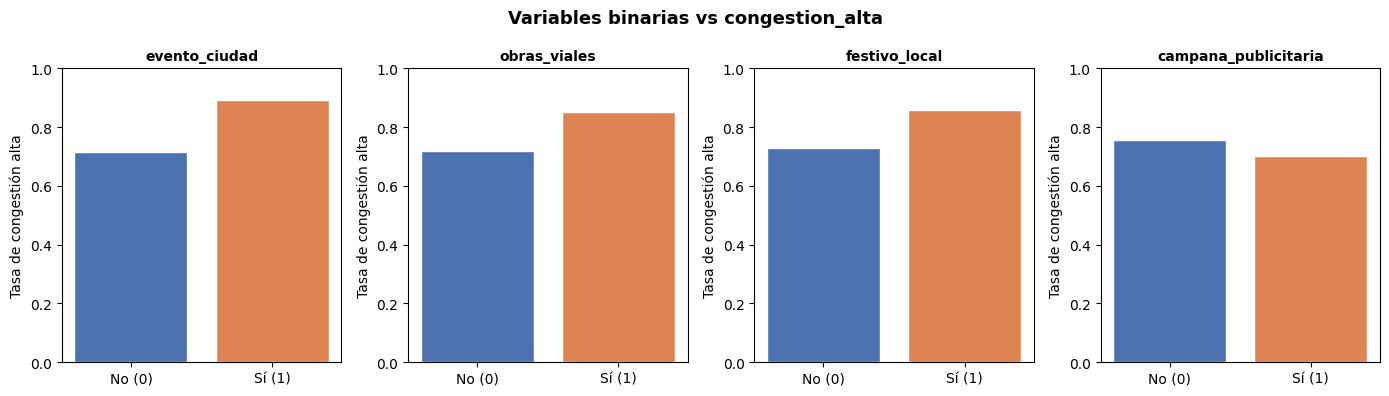

In [24]:
binarias = ['evento_ciudad', 'obras_viales', 'festivo_local', 'campana_publicitaria']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i, var in enumerate(binarias):
    tasa = data.groupby(var)['congestion_alta'].mean()
    axes[i].bar(tasa.index.astype(str), tasa.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Tasa de congestión alta')
    axes[i].set_ylim(0, 1)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No (0)', 'Sí (1)'])

plt.suptitle('Variables binarias vs congestion_alta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**evento_ciudad:** Cuando hay un evento en la ciudad la tasa de congestión alta sube hasta 0.90, frente al 0.72 cuando no hay evento. Es la variable binaria con mayor diferencia entre grupos, lo que la convierte en una buena candidata predictora.

**obras_viales:** La presencia de obras viales eleva la tasa de congestión alta hasta 0.85 frente al 0.72 sin obras. Tiene sentido, las obras reducen la capacidad de la vía y generan cuellos de botella.

**festivo_local:** Los días festivos tienen una tasa de congestión alta de 0.86 frente al 0.73 de los días no festivos. Sorprendentemente los festivos tienen más congestión, lo que podría explicarse por eventos, desplazamientos de ocio o concentración de actividad en zonas concretas.

**campana_publicitaria:** Es la única variable binaria con comportamiento inverso. Cuando hay campaña publicitaria la tasa baja ligeramente a 0.70 frente al 0.76 sin campaña. La diferencia es pequeña y probablemente no sea significativa, por lo que esta variable aportará poco al modelo.

### Variable de id_sensor

Aunque `id_sensor` es un identificador, puede ser informativo analizar si hay sensores que registran sistemáticamente más congestión alta que otros, lo que indicaría que su ubicación geográfica es relevante.

La siguiente tabla muestra los 10 sensores con mayor tasa de congestión alta:

In [41]:
resumen_sensor = data.groupby('id_sensor')['congestion_alta'].agg(
    tasa_congestion = 'mean',
    numero_registros_sensor = 'count',
    numero_congestion_alta = 'sum'
)

resumen_sensor['numero_congestion_no_alta'] = resumen_sensor['numero_registros_sensor']-resumen_sensor['numero_congestion_alta']

resumen_sensor.sort_values('tasa_congestion',ascending=False).head(10)

,tasa_congestion,numero_registros_sensor,numero_congestion_alta,numero_congestion_no_alta
id_sensor,,,,
S-037,1.000000,12,12,0
S-014,0.937500,16,15,1
S-009,0.916667,12,11,1
S-016,0.909091,11,10,1
S-004,0.900000,10,9,1
S-019,0.875000,16,14,2
S-031,0.866667,15,13,2
S-036,0.866667,15,13,2
S-012,0.866667,15,13,2


El sensor S-037 registra congestión alta en el 100% de sus registros, lo que sugiere que está ubicado en una zona especialmente conflictiva. Sin embargo, incluir `id_sensor` directamente como predictor tiene dos problemas.

El primero es el overfitting. Con 50 sensores distintos y una media de solo 14 registros por sensor, el modelo podría memorizar qué sensores tienen más congestión en los datos de entrenamiento sin aprender patrones generalizables. Si en producción aparece un sensor nuevo o con pocos registros históricos, el modelo no sabría qué hacer con él.

El segundo es el data leakage. Una alternativa sería crear una variable derivada con la tasa histórica de congestión por sensor, pero esa tasa se calcularía con datos del propio dataset, lo que puede contaminar el modelo si no se hace correctamente separando siempre entrenamiento y test.

Por tanto, `id_sensor` se excluye del modelo. Las variables `distrito` y `franja_horaria` ya capturan implícitamente la información geográfica y temporal que el sensor podría aportar.

### Análisis de la variable fecha

La variable `fecha` no puede usarse directamente como predictor ya que es una cadena de texto con una fecha concreta. Sin embargo, contiene información temporal valiosa que se puede extraer en forma de variables derivadas como el mes, el trimestre o la semana del año.

El objetivo es detectar si hay patrones estacionales en la congestión alta, es decir, si hay meses o épocas del año con más congestión que otras. Si existen esos patrones, tendría sentido crear variables derivadas a partir de `fecha` para incluirlas en el modelo.

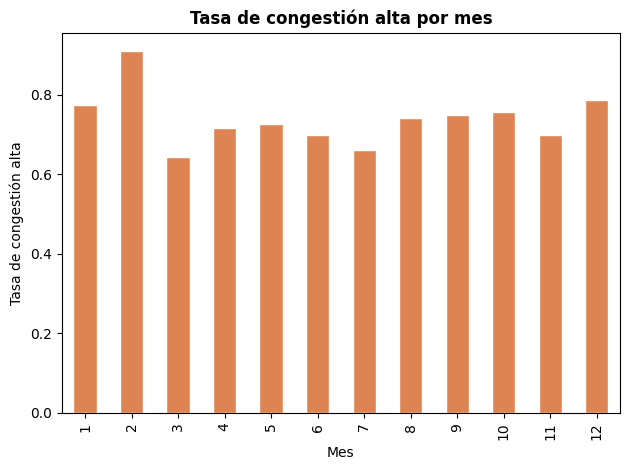

In [43]:
data['fecha']= pd.to_datetime(data['fecha'])
data['mes'] = data['fecha'].dt.month
data.groupby('mes')['congestion_alta'].mean().plot(kind='bar', color='#DD8452', edgecolor='white')
plt.title('Tasa de congestión alta por mes', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de congestión alta')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()

El gráfico muestra la tasa de congestión alta por mes. Se observan algunas variaciones pero sin un patrón estacional claro y consistente. Febrero destaca con la tasa más alta (0.90) y marzo con la más baja (0.64), pero el resto de meses se mantiene en un rango bastante estrecho entre 0.65 y 0.78.

La ausencia de un patrón estacional claro sugiere que el mes por sí solo no es un predictor fuerte de la congestión alta. Sin embargo, dado que el dataset solo tiene 720 registros repartidos entre 12 meses, hay pocos registros por mes y las tasas pueden estar influenciadas por el azar más que por patrones reales.

Por tanto, se podría incluir el mes como variable derivada de `fecha` en la fase de preparación de datos, pero con cautela. La variable `fecha` original se descartará del modelo ya que no puede usarse directamente como predictor.

In [46]:
data['año']= data['fecha'].dt.year

data['año'].value_counts() # todos los registros son de 2025

año
2025    720
Name: count, dtype: int64

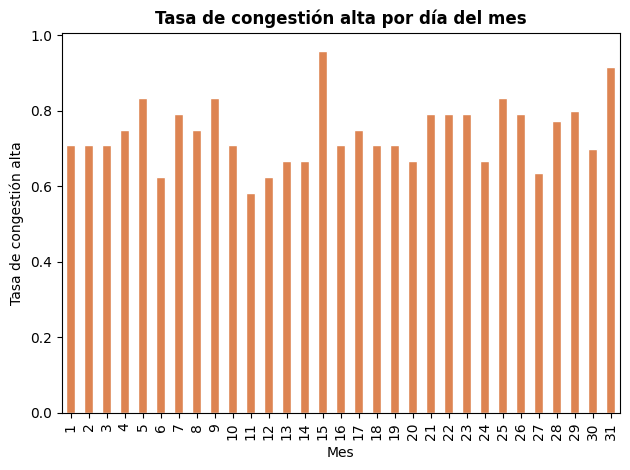

In [49]:
data['dia'] = data['fecha'].dt.day
data.groupby('dia')['congestion_alta'].mean().plot(kind='bar', color='#DD8452', edgecolor='white')
plt.title('Tasa de congestión alta por día del mes', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de congestión alta')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()

Analizando la tasa de congestión alta por día del mes tampoco se observa ningún patrón claro. Los valores oscilan aleatoriamente entre 0.59 y 0.95 sin ninguna tendencia identificable. Esto confirma que el día del mes no aporta información predictiva útil y no se creará una variable derivada a partir de él. Solo se extraerá el mes de `fecha` para capturar posible estacionalidad mensual.

### Variables que podrían requerir transformación

Antes de entrenar el modelo es importante analizar si las variables numéricas necesitan algún tipo de transformación. Hay tres aspectos clave a revisar.

El primero son los **rangos y escalas**. Si las variables tienen escalas muy distintas entre sí, como `aforo_vehiculos` que va de 350 a 2785 y `lluvia_mm` que va de 0 a 28, los modelos sensibles a la escala como la regresión logística o los basados en distancias pueden verse afectados. En ese caso se aplica escalado, normalizando todas las variables a un rango común.

El segundo es la **asimetría o skewness**. Si una variable tiene su distribución muy sesgada hacia un lado, con una cola larga, puede beneficiarse de una transformación logarítmica o de raíz cuadrada para aproximarla a una distribución más simétrica y mejorar el rendimiento del modelo.

El tercero son los **outliers**. Valores extremos muy alejados de la media pueden distorsionar el aprendizaje del modelo. Es importante detectarlos y decidir si eliminarlos, capearlos o transformarlos.

A continuación analizamos cada uno de estos aspectos sobre las variables numéricas del dataset.

In [47]:
variables_numericas = [
    'aforo_vehiculos', 'indice_ruido_historico', 'accidentes_previos_24h',
    'ocupacion_bus_pct', 'numero_incidencias_app', 'porcentaje_hombres_zona',
    'lluvia_mm', 'viento_kmh', 'humedad_relativa_pct', 'temperatura_c',
    'ocupacion_bici_pct', 'plazas_aparcamiento_libres'
]

resumen = data[variables_numericas].agg(['min', 'max', 'mean', 'std', 'skew']).T
resumen['rango'] = resumen['max'] - resumen['min']
resumen = resumen[['min', 'max', 'rango', 'mean', 'std', 'skew']].round(2)
print(resumen)

                              min     max   rango     mean     std  skew
aforo_vehiculos             350.0  2785.0  2435.0  1503.36  473.64 -0.18
indice_ruido_historico       58.4   125.0    66.6    88.02   11.89  0.01
accidentes_previos_24h        0.0     7.0     7.0     3.72    1.33  0.03
ocupacion_bus_pct            28.5   100.0    71.5    69.39   13.29 -0.16
numero_incidencias_app        0.0    18.0    18.0     7.96    3.16  0.07
porcentaje_hombres_zona      48.0    55.2     7.2    51.54    1.28 -0.09
lluvia_mm                     0.0    28.5    28.5     3.34    4.04  2.25
viento_kmh                    0.0    28.3    28.3    12.75    4.84  0.16
humedad_relativa_pct         25.0    95.0    70.0    58.93   13.79  0.08
temperatura_c               -10.1    38.0    48.1    16.61    7.44  0.04
ocupacion_bici_pct            1.2    66.9    65.7    35.28   10.26  0.04
plazas_aparcamiento_libres   31.0   327.0   296.0   179.79   49.65  0.00


Las variables tienen rangos muy distintos entre sí. `aforo_vehiculos` tiene un rango de 2.435 (de 350 a 2.785) mientras que `porcentaje_hombres_zona` tiene un rango de solo 7.2 (de 48 a 55.2). Esta diferencia de escala es enorme y afectará directamente a modelos sensibles a la magnitud como la regresión logística o los basados en distancias, que interpretarán `aforo_vehiculos` como mucho más importante simplemente por tener valores más grandes. Por eso todas las variables numéricas deberán escalarse antes de entrenar ese tipo de modelos.

La gran mayoría de variables tienen skewness cercana a 0, lo que indica distribuciones bastante simétricas. La excepción clara es `lluvia_mm` con skewness de 2.25, muy sesgada a la derecha: la mayoría de días llueve poco o nada pero hay episodios puntuales de lluvia intensa que estiran la cola derecha. Es la única candidata clara a transformación logarítmica.

`porcentaje_hombres_zona` tiene una desviación típica de solo 1.28 con una media de 51.54, lo que significa que prácticamente todos los registros tienen valores muy similares entre 48 y 55. Una variable con tan poca variabilidad aportará muy poco al modelo ya que casi no discrimina entre registros.

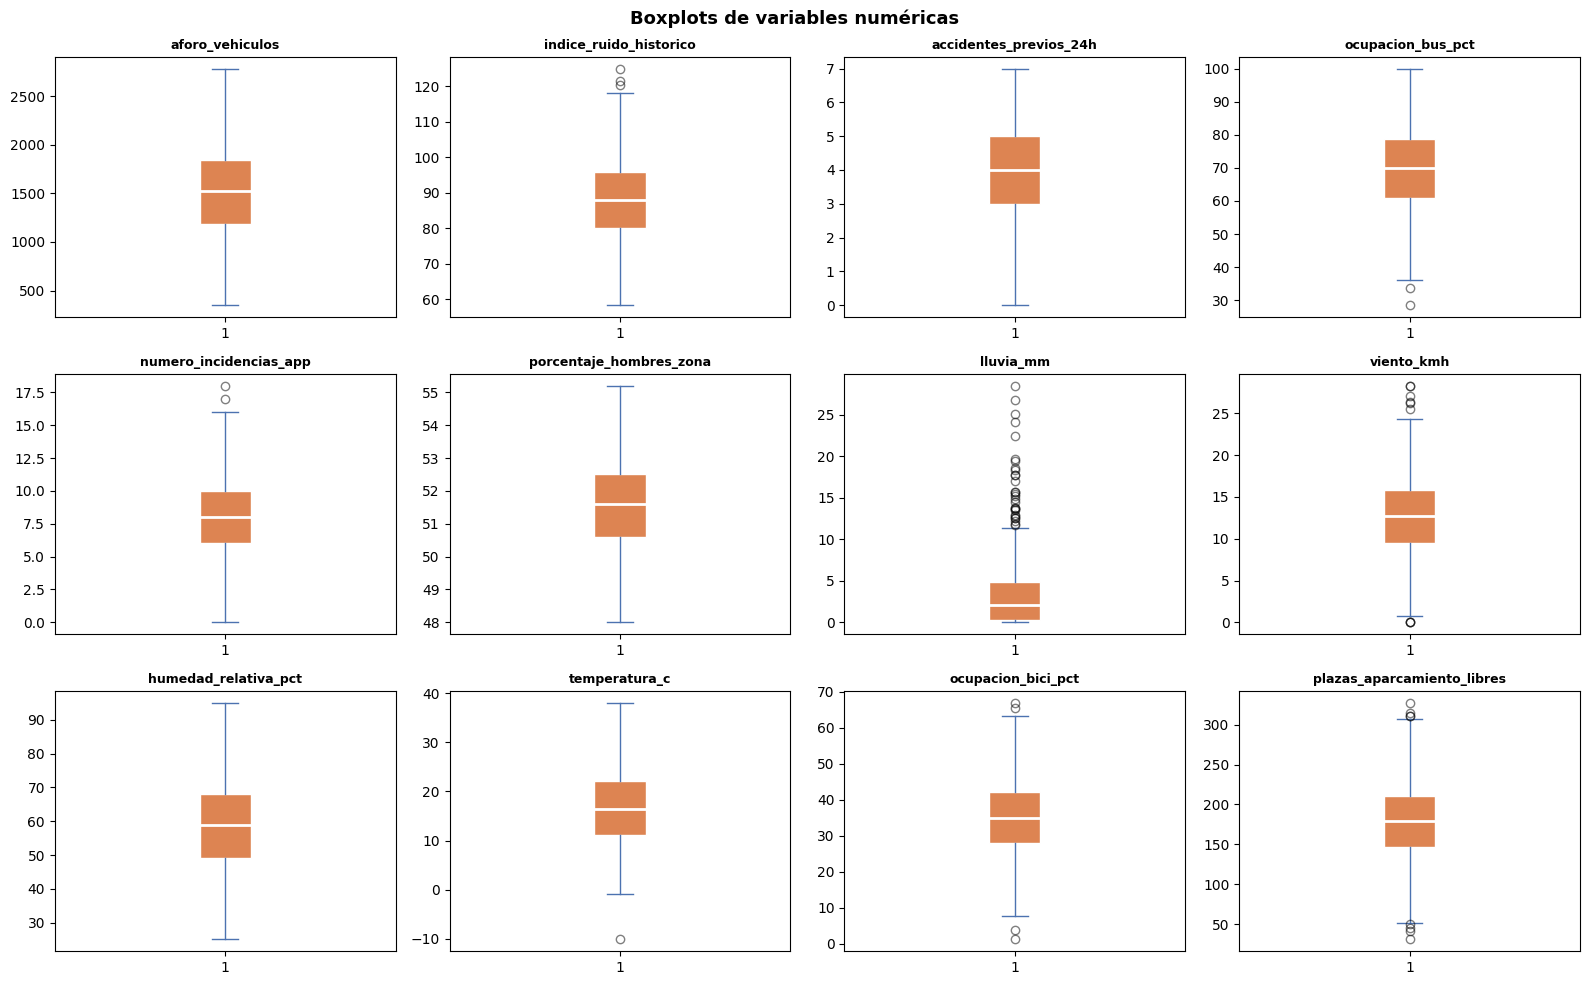

In [48]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    axes[i].boxplot(data[var].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#DD8452', color='white'),
                   medianprops=dict(color='white', linewidth=2),
                   whiskerprops=dict(color='#4C72B0'),
                   capprops=dict(color='#4C72B0'),
                   flierprops=dict(marker='o', color='#4C72B0', alpha=0.5))
    axes[i].set_title(var, fontsize=9, fontweight='bold')

plt.suptitle('Boxplots de variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Los boxplots permiten visualizar la dispersión, la mediana y los outliers de cada variable numérica. Los puntos que aparecen fuera de los bigotes son valores atípicos.

**Variables con outliers destacables:**

`lluvia_mm` es la variable con más outliers visibles, con numerosos puntos por encima de 15mm. Esto confirma el skewness de 2.25 que vimos antes: la mayoría de registros tienen lluvia baja o nula pero hay episodios puntuales de lluvia intensa. Es la candidata más clara a transformación logarítmica.

`indice_ruido_historico` tiene dos puntos por encima de 115, claramente alejados del resto de valores que se concentran entre 60 y 110. Podrían ser outliers reales o errores de medición.

`numero_incidencias_app` tiene un punto en 17-18 incidencias, bastante por encima del rango habitual de 0 a 12. `ocupacion_bici_pct` y `plazas_aparcamiento_libres` también muestran algún punto aislado en los extremos.

`temperatura_c` tiene un valor mínimo de -10.1 que aparece como outlier inferior, coherente con una ola de frío puntual.

**Variables sin outliers relevantes:**

`aforo_vehiculos`, `humedad_relativa_pct`, `viento_kmh`, `ocupacion_bus_pct` y `accidentes_previos_24h` muestran distribuciones limpias sin valores atípicos destacables.

**Variables con rango muy estrecho:**

`porcentaje_hombres_zona` tiene un rango de solo 7.2 puntos (48 a 55.2) y una caja muy compacta. Prácticamente no varía entre registros, lo que sugiere que esta variable aportará muy poco poder predictivo al modelo.


`lluvia_mm` necesita transformación logarítmica por su fuerte asimetría. Todas las variables numéricas necesitarán escalado antes de entrenar modelos sensibles a la magnitud como la regresión logística. Los outliers detectados son en su mayoría valores extremos pero plausibles, por lo que no se eliminarán sino que se caparán si es necesario en la fase de preparación.

### Act 2: comprensión del dataset

#### Variable objetivo

| Variable | Justificación |
|---|---|
| `congestion_alta` | Variable binaria (0/1) que indica si hay congestión alta. Es la variable que el modelo debe predecir. |


### Variables candidatas a predictoras

| Variable | Justificación |
|---|---|
| `aforo_vehiculos` | Mayor correlación con el target (0.42). Cuantos más vehículos, más congestión. |
| `indice_ruido_historico` | Correlación moderada (0.30). Las zonas más ruidosas tienden a tener más congestión. |
| `accidentes_previos_24h` | Correlación moderada (0.26). Más accidentes previos, más congestión. |
| `ocupacion_bus_pct` | Correlación moderada (0.22). Refleja demanda de movilidad elevada en la zona. |
| `plazas_aparcamiento_libres` | Correlación negativa (-0.17). Más plazas libres, menos congestión. |
| `dia_semana_num` | Correlación negativa (-0.15). Los días de fin de semana tienen menos congestión. |
| `evento_ciudad` | Mayor diferencia entre grupos (0.72 sin evento vs 0.90 con evento). |
| `obras_viales` | Diferencia clara entre grupos (0.72 sin obras vs 0.85 con obras). |
| `festivo_local` | Diferencia entre grupos (0.73 sin festivo vs 0.86 con festivo). |
| `franja_horaria` | Gran diferencia entre franjas. Noche (0.44) vs mañana y tarde (0.82-0.83). |
| `tipo_dia` | Diferencia clara. Laborable (0.78) vs fin de semana (0.63). |
| `distrito` | Diferencia entre distritos. Centro (0.85) vs Sur (0.65). |
| `numero_incidencias_app` | Correlación baja pero positiva (0.13). Más incidencias, más congestión. |
| `lluvia_mm` | Correlación baja (0.10) pero puede tener relación no lineal con la congestión. |
| `ocupacion_bici_pct` | Correlación negativa leve (-0.05). Más uso de bici, ligeramente menos congestión. |
| `mes` | Variable derivada de `fecha`. Puede capturar estacionalidad. |


### Posibles variables no relevantes

| Variable | Justificación |
|---|---|
| `id_registro` | Índice de fila sin información predictiva. |
| `id_sensor` | Identificador con 50 valores distintos y pocos registros por sensor. Su inclusión causaría overfitting. |
| `fecha` | No puede usarse directamente. Se puede derivar el mes. |
| `color_semaforo_dominante` | Tasas muy similares entre categorías (0.71-0.75). Prácticamente no discrimina. |
| `campana_publicitaria` | Correlación muy baja (-0.06) y diferencia entre grupos mínima. |
| `viento_kmh` | Correlación prácticamente nula (0.006). |
| `humedad_relativa_pct` | Correlación prácticamente nula (-0.007). |
| `temperatura_c` | Correlación prácticamente nula (-0.013). |
| `porcentaje_hombres_zona` | Rango de solo 7.2 puntos y desviación típica de 1.28. Prácticamente no varía entre registros. |


### Variables que pueden causar sesgo

| Variable | Justificación |
|---|---|
| `indice_congestion` | Está directamente relacionada con `congestion_alta`. Usarla como predictor causaría data leakage: el modelo aprendería a predecir el target usando información que en producción real ya implica conocer la respuesta. Debe excluirse. |
| `porcentaje_hombres_zona` | Variable demográfica de género que no tiene justificación causal clara con la congestión. Su inclusión podría introducir sesgo sin mejorar el modelo. |


### Variables que requieren transformación

| Variable | Transformación necesaria | Justificación |
|---|---|---|
| `lluvia_mm` | Transformación logarítmica | Skewness de 2.25, distribución muy sesgada a la derecha con muchos valores cercanos a 0 y episodios puntuales de lluvia intensa. |
| `aforo_vehiculos` | Escalado | Rango de 2.435, mucho mayor que el resto de variables. |
| `plazas_aparcamiento_libres` | Escalado | Rango de 296, escala muy distinta al resto. |
| `indice_ruido_historico` | Escalado | Rango de 66.6 con outliers por encima de 115. |
| `ocupacion_bus_pct` | Escalado | Rango de 71.5. |
| `humedad_relativa_pct` | Escalado | Rango de 70. |
| `temperatura_c` | Escalado | Rango de 48.1 con valor mínimo de -10.1. |
| `distrito` | Codificación One-Hot Encoding | Variable categórica con 6 categorías sin orden natural. |
| `franja_horaria` | Codificación One-Hot Encoding | Variable categórica con 3 categorías sin orden natural. |
| `tipo_dia` | Codificación binaria | Variable categórica con solo 2 categorías (Laborable/Fin de semana). |
| `color_semaforo_dominante` | Codificación One-Hot Encoding | Variable categórica con 3 categorías sin orden natural. Aunque probablemente se descarte por ser poco relevante. |
| `dia_semana_num` | Ya codificada numéricamente | Podría tratarse como categórica con One-Hot Encoding si se quiere evitar que el modelo asuma orden entre días. |
| `mes` | Codificación cíclica o One-Hot Encoding | Variable derivada de fecha. Al ser cíclica (enero sigue a diciembre) podría codificarse con seno y coseno. |

## Preparación de los datos

En esta sección preparamos el dataset para poder entrenar los modelos. A partir del análisis exploratorio del Act 2 ya sabemos qué variables incluir, cuáles descartar y qué transformaciones necesitan a priori. El objetivo es dejar el dataset limpio y listo para el entrenamiento.

Los pasos que seguiremos son los siguientes. Primero eliminaremos las variables que hemos decidido no usar. Segundo trataremos los valores ausentes de las variables que los tienen. Tercero crearemos variables derivadas como el mes a partir de fecha. Cuarto aplicaremos la transformación logarítmica a lluvia_mm. Quinto codificaremos las variables categóricas. Sexto escalaremos las variables numéricas. Y por último realizaremos la partición entre datos de entrenamiento y datos de prueba.

### Paso 1: Eliminación de variables claras

En este paso eliminamos únicamente las variables que tienen razones objetivas e irrefutables para ser descartadas, independientemente del modelo que se vaya a entrenar. Las variables con correlación baja como `color_semaforo_dominante` o `campana_publicitaria` no se eliminan aquí — se dejará que el propio modelo determine su importancia mediante las métricas de importancia de variables en fases posteriores.

Las variables eliminadas y su justificación son las siguientes:

`id_registro` es un índice de fila sin ninguna información predictiva, su único papel es identificar cada registro de forma única.

`id_sensor` es un identificador con 50 valores distintos y pocos registros por sensor (media de 14 registros), lo que causaría overfitting ya que el modelo memorizaría qué sensores tienen más congestión en entrenamiento sin aprender patrones generalizables.

`fecha` no puede usarse directamente como predictor. Se sustituye por la variable derivada `mes` que captura posible estacionalidad mensual.

`año` y `dia` son variables creadas durante la exploración inicial. `año` no discrimina porque todos los registros son de 2025, y el análisis por día del mes mostró que no existe ningún patrón claro en la tasa de congestión alta.

`indice_congestion` causaría data leakage al estar directamente relacionada con `congestion_alta`. El modelo aprendería a predecir el target usando información que en producción real ya implica conocer la respuesta, generando resultados artificialmente buenos que no se reproducirían fuera del dataset.

In [51]:
data.columns

Index(['id_registro', 'fecha', 'dia_semana_num', 'distrito', 'tipo_dia',
       'franja_horaria', 'id_sensor', 'temperatura_c', 'humedad_relativa_pct',
       'lluvia_mm', 'viento_kmh', 'evento_ciudad', 'obras_viales',
       'festivo_local', 'aforo_vehiculos', 'accidentes_previos_24h',
       'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct',
       'numero_incidencias_app', 'indice_ruido_historico',
       'color_semaforo_dominante', 'campana_publicitaria',
       'porcentaje_hombres_zona', 'indice_congestion', 'congestion_alta',
       'mes', 'año', 'dia'],
      dtype='str')

In [57]:
variables_eliminar = [
    'id_registro',
    'id_sensor', 
    'fecha',
    'año',
    'dia',
    'indice_congestion'
]

data_clean = data.drop(columns=variables_eliminar)
print(f"Variables antes de eliminar", data.shape[1])
print(f"Variables al eliminar", data_clean.shape[1])
print(data_clean.columns.tolist())

Variables antes de eliminar 29
Variables al eliminar 23
['dia_semana_num', 'distrito', 'tipo_dia', 'franja_horaria', 'temperatura_c', 'humedad_relativa_pct', 'lluvia_mm', 'viento_kmh', 'evento_ciudad', 'obras_viales', 'festivo_local', 'aforo_vehiculos', 'accidentes_previos_24h', 'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct', 'numero_incidencias_app', 'indice_ruido_historico', 'color_semaforo_dominante', 'campana_publicitaria', 'porcentaje_hombres_zona', 'congestion_alta', 'mes']


### Paso 2: Tratamiento de variables con baja variabilidad y sesgo potencial

Antes de continuar con el resto de transformaciones, identificamos las variables con variabilidad tan baja que prácticamente no pueden discriminar entre registros, o que pueden introducir sesgo en el modelo.

`porcentaje_hombres_zona` se elimina por dos razones. La primera es su baja variabilidad: tiene un rango de solo 7.2 puntos (de 48 a 55.2) y una desviación típica de 1.28 sobre una media de 51.54, lo que significa que casi todos los registros tienen valores muy similares entre sí y el modelo no puede aprender nada útil de ella. La segunda es el sesgo potencial: no existe justificación causal entre la distribución de género de una zona y la congestión del tráfico, y su inclusión podría hacer que el modelo tomara decisiones distintas según la composición demográfica de la zona, lo cual podría considerarse discriminatorio en un sistema operativo municipal.

In [58]:
data_clean = data_clean.drop(columns=['porcentaje_hombres_zona'])
print(f"Variables tras eliminar baja variabilidad: {data_clean.shape[1]}")

Variables tras eliminar baja variabilidad: 22


> Es importante destacar que aunque en el análisis exploratorio identificamos variables con correlación baja o tasas de congestión similares entre categorías, como `color_semaforo_dominante`, `campana_publicitaria`, `viento_kmh`, `humedad_relativa_pct` o `temperatura_c`, hemos decidido no eliminarlas en esta fase. La correlación lineal y el análisis univariante tienen limitaciones: una variable puede parecer poco relevante de forma individual pero aportar información útil al modelo en combinación con otras variables, o tener relaciones no lineales con el target que estos análisis no capturan. Dejaremos que el propio modelo determine su importancia en fases posteriores mediante las métricas de importancia de variables.

### Paso 3: Tratamiento de valores ausentes

Antes de entrenar cualquier modelo es necesario tratar los valores ausentes del dataset. En el análisis exploratorio observamos que varias variables numéricas tienen registros con valores nulos. En este paso identificamos exactamente cuántos nulos hay en cada variable y decidimos cómo tratarlos.

In [69]:
nulos = data.isna().sum().sort_values(ascending=False) # cantidad de valores nulos por variable

In [ ]:
nulos[nulos>0] # recordatorio: sobre la misma boolean mask

lluvia_mm                     10
franja_horaria                 9
distrito                       9
temperatura_c                  7
ocupacion_bus_pct              5
accidentes_previos_24h         5
numero_incidencias_app         4
humedad_relativa_pct           4
viento_kmh                     3
indice_ruido_historico         3
ocupacion_bici_pct             2
plazas_aparcamiento_libres     2
dtype: int64

Primero se tiene que analizar que tipo de valores nulos son, y la razon por la que existen estos valores nulos. De esta manera se decide como tratar con ellos:

#### Registros nulos en la variable lluvia_mm

Hay 10 nulos en esta variable que corresponden a un 1.39% del dataset total. Las razones tras estos valores nulos pueden ser diversas. Tratamos de entender cual es más probable.

In [93]:
data_clean['lluvia_mm'].isna().mean()*100 # porcentaje de nulos respecto al total

np.float64(1.3888888888888888)

In [94]:
nulos_lluvia = data_clean[data_clean['lluvia_mm'].isna()]

In [95]:
nulos_lluvia.info() # cuando la lluvia es nula no hay otra variable que tb sea nula-> descartamos caso de nulidad por otra variable

<class 'pandas.DataFrame'>
Index: 10 entries, 16 to 690
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dia_semana_num              10 non-null     int64  
 1   distrito                    10 non-null     str    
 2   tipo_dia                    10 non-null     str    
 3   franja_horaria              10 non-null     str    
 4   temperatura_c               10 non-null     float64
 5   humedad_relativa_pct        10 non-null     float64
 6   lluvia_mm                   0 non-null      float64
 7   viento_kmh                  10 non-null     float64
 8   evento_ciudad               10 non-null     int64  
 9   obras_viales                10 non-null     int64  
 10  festivo_local               10 non-null     int64  
 11  aforo_vehiculos             10 non-null     int64  
 12  accidentes_previos_24h      10 non-null     float64
 13  ocupacion_bus_pct           10 non-null     float64

In [96]:
print(f"Registros con lluvia_mm = 0: {(data_clean['lluvia_mm'] == 0).sum()}")
print(f"Registros con lluvia_mm > 0: {(data_clean['lluvia_mm'] > 0).sum()}")
print(f"Registros con lluvia_mm nula: {data_clean['lluvia_mm'].isna().sum()}")
print(f"\nMediana de lluvia_mm: {data_clean['lluvia_mm'].median()}")
print(f"Media de lluvia_mm: {data_clean['lluvia_mm'].mean().round(2)}")

Registros con lluvia_mm = 0: 140
Registros con lluvia_mm > 0: 570
Registros con lluvia_mm nula: 10

Mediana de lluvia_mm: 2.1
Media de lluvia_mm: 3.34


In [97]:
data_clean['lluvia_mm'].describe() # distribucion de lluvia en el dataset 

count    710.000000
mean       3.344366
std        4.044703
min        0.000000
25%        0.300000
50%        2.100000
75%        4.800000
max       28.500000
Name: lluvia_mm, dtype: float64

Los 140 registros con lluvia igual a 0 confirman que cuando no llueve el sensor registra explícitamente 0, no un valor nulo. Por tanto los 10 nulos no representan días sin lluvia sino fallos puntuales del sensor o errores en la recogida de datos.

Dado que son solo el 1.39% del total y que la distribución de `lluvia_mm` está fuertemente sesgada a la derecha (skewness 2.25), se imputa con la mediana (2.1mm) en lugar de la media (3.34mm), ya que la mediana es más robusta ante la asimetría y los valores extremos.

In [ ]:
data_clean['lluvia_mm'].median() # vamos a imputar los 10 nulos con este valor 

np.float64(2.1)

In [101]:
data_clean['lluvia_mm'] = data_clean['lluvia_mm'].fillna(data_clean['lluvia_mm'].median())

print(f"Nulos restantes en lluvia_mm: {data_clean['lluvia_mm'].isna().sum()}")

Nulos restantes en lluvia_mm: 0


#### Registros nulos en la variable franja_horaria

Hay 9 nulos en franja horaria que corresponden a un 1.25% de registros del total. De la misma forma se analiza la razón del valor nulo.

In [112]:
data_clean['franja_horaria'].unique() # recordamos valores q tomaba

<StringArray>
['Mañana', 'Tarde', nan, 'Noche']
Length: 4, dtype: str

In [105]:
data_clean['franja_horaria'].isna().sum(), data_clean['franja_horaria'].isna().mean()*100

(np.int64(9), np.float64(1.25))

In [106]:
nulos_franja_horaria = data_clean[data_clean['franja_horaria'].isna()]

In [107]:
nulos_franja_horaria.info()

<class 'pandas.DataFrame'>
Index: 9 entries, 8 to 447
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dia_semana_num              9 non-null      int64  
 1   distrito                    9 non-null      str    
 2   tipo_dia                    9 non-null      str    
 3   franja_horaria              0 non-null      str    
 4   temperatura_c               9 non-null      float64
 5   humedad_relativa_pct        9 non-null      float64
 6   lluvia_mm                   9 non-null      float64
 7   viento_kmh                  8 non-null      float64
 8   evento_ciudad               9 non-null      int64  
 9   obras_viales                9 non-null      int64  
 10  festivo_local               9 non-null      int64  
 11  aforo_vehiculos             9 non-null      int64  
 12  accidentes_previos_24h      9 non-null      float64
 13  ocupacion_bus_pct           9 non-null      float64
 

Al analizar estos registros se observa que a la par existen nulos en `viento_kmh` y `ocupacion_bici_pct`, concretamente un registro con nulo en viento y otro con nulo en ocupación de bici. De nuevo los valores nulos no parecen depender del valor de ninguna otra variable ni seguir un patrón claro, apuntando a fallos puntuales en la recogida de datos.

Al tratarse `franja_horaria` de una variable categórica, no tiene sentido imputar con media o mediana. Las opciones son eliminar los 9 registros afectados o imputar con la moda, es decir, con la categoría más frecuente. Dado que son solo el 1.25% del total, eliminar esas filas es la opción más limpia y segura ya que evita introducir ruido artificialmente en una variable tan relevante para el modelo, que como vimos en el análisis exploratorio es una de las más discriminativas.

In [113]:
nulos_franja_horaria[(nulos_franja_horaria['ocupacion_bici_pct'].isna()) | (nulos_franja_horaria['viento_kmh'].isna())] 
# era para ver si los nulos estaban relacionados entre si-> no parece

,dia_semana_num,distrito,tipo_dia,franja_horaria,temperatura_c,humedad_relativa_pct,lluvia_mm,viento_kmh,evento_ciudad,obras_viales,...,accidentes_previos_24h,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,color_semaforo_dominante,campana_publicitaria,congestion_alta,mes
101,3,Norte,Laborable,NaN,21.8,47.0,2.3,10.3,0,1,...,2.0,66.9,153.0,NaN,16.0,89.1,Rojo,0,1,2
329,5,Oeste,Fin de semana,NaN,19.6,74.0,9.4,NaN,0,0,...,2.0,61.5,234.0,49.1,4.0,65.5,Amarillo,0,0,6


> Duda más normal en este punto: ¿Por qué imputar lluvia pero en este caso franja horaria con la moda no? franja_horaria es categórica: sus valores son etiquetas (Mañana, Tarde, Noche). La moda sería imputar todos los nulos con "Tarde" por ejemplo, pero eso introduce información falsa en una variable muy discriminativa. Si esos 9 registros son en realidad de noche y los imputamos como tarde, el modelo aprende mal. Con tan pocos registros es más limpio eliminarlos. En cambio, lluvia_mm es numérica: la mediana es un valor representativo y plausible, no introduce información falsa. En variables categóricas el error de imputación es binario, o aciertas la categoría correcta o te equivocas completamente. En variables numéricas hay un gradiente ya que puedes estar más o menos cerca del valor real, y la mediana es una aproximación razonable que introduce poco error.


In [ ]:
data_clean = data_clean[data_clean['franja_horaria'].notna()]  # eliminamos los nulos en franja horaria

#### Valores nulos en la variable distrito

Hay 9 nulos en `distrito` que corresponden a un 1.25% del total. Los registros afectados tienen todas las demás variables completas, apuntando de nuevo a un fallo puntual en la recogida de datos. Al ser `distrito` una variable categórica muy discriminativa (vimos en el análisis exploratorio que la tasa de congestión varía entre 0.65 en Sur y 0.85 en Centro), imputar con la moda asignaría el mismo distrito a todos los registros sin garantía de que sea el correcto. Se eliminan las filas afectadas.

In [123]:
data_clean['distrito'].unique()

<StringArray>
['Centro', 'Este', 'Universidad', 'Sur', 'Oeste', 'Norte', nan]
Length: 7, dtype: str

In [124]:
nulos_distrito = data_clean[data_clean['distrito'].isna()]

In [126]:
nulos_distrito.info()

<class 'pandas.DataFrame'>
Index: 9 entries, 32 to 670
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dia_semana_num              9 non-null      int64  
 1   distrito                    0 non-null      str    
 2   tipo_dia                    9 non-null      str    
 3   franja_horaria              9 non-null      str    
 4   temperatura_c               9 non-null      float64
 5   humedad_relativa_pct        9 non-null      float64
 6   lluvia_mm                   9 non-null      float64
 7   viento_kmh                  9 non-null      float64
 8   evento_ciudad               9 non-null      int64  
 9   obras_viales                9 non-null      int64  
 10  festivo_local               9 non-null      int64  
 11  aforo_vehiculos             9 non-null      int64  
 12  accidentes_previos_24h      9 non-null      float64
 13  ocupacion_bus_pct           9 non-null      float64


In [130]:
# solucion
data_clean = data_clean[data_clean['distrito'].notna()]

#### Valores nulos en variables numéricas

El resto de variables numéricas tienen un número muy reducido de nulos, todos por debajo del 1% del total. Al ser variables numéricas continuas y con tan pocos nulos, se imputan todas con la mediana de cada variable.

| Variable | Nulos | Porcentaje |
|---|---|---|
| `temperatura_c` | 7 | 0.97% |
| `accidentes_previos_24h` | 5 | 0.69% |
| `ocupacion_bus_pct` | 5 | 0.69% |
| `humedad_relativa_pct` | 4 | 0.55% |
| `numero_incidencias_app` | 4 | 0.55% |
| `indice_ruido_historico` | 3 | 0.42% |
| `plazas_aparcamiento_libres` | 2 | 0.28% |
| `viento_kmh` | 2 | 0.28% |
| `ocupacion_bici_pct` | 1 | 0.14% |

In [133]:
variables_mediana = [
    'temperatura_c', 'humedad_relativa_pct', 'viento_kmh',
    'accidentes_previos_24h', 'ocupacion_bus_pct', 'plazas_aparcamiento_libres',
    'ocupacion_bici_pct', 'numero_incidencias_app', 'indice_ruido_historico'
]

for col in variables_mediana:
    print(f"Mediana variable", col, ":", data_clean[col].median())
    data_clean[col]= data_clean[col].fillna(data_clean[col].mean())

print(data_clean[variables_mediana].isna().sum())

Mediana variable temperatura_c : 16.4
Mediana variable humedad_relativa_pct : 59.0
Mediana variable viento_kmh : 12.7
Mediana variable accidentes_previos_24h : 4.0
Mediana variable ocupacion_bus_pct : 69.9
Mediana variable plazas_aparcamiento_libres : 179.0
Mediana variable ocupacion_bici_pct : 35.0
Mediana variable numero_incidencias_app : 8.0
Mediana variable indice_ruido_historico : 88.3
temperatura_c                 0
humedad_relativa_pct          0
viento_kmh                    0
accidentes_previos_24h        0
ocupacion_bus_pct             0
plazas_aparcamiento_libres    0
ocupacion_bici_pct            0
numero_incidencias_app        0
indice_ruido_historico        0
dtype: int64
